# Feature Explainability Plots for DRD2-Hi

 This notebook produces all feature-level explainability figures.

 It reads the CSV tables built by `05_feature_explainability_tables_drd2.ipynb`
 and produces:

 1. **Absolute importance distribution** — boxplot per protocol × model × fingerprint
 2. **Top-k protocol overlap** — barplot per model
 3. **Cumulative importance curves** — per protocol × fingerprint
 4. **Decision Tree minimum depth distribution** — boxplot per protocol
 5. **Intra-protocol stability heatmaps** — fold-pair × k
 6. **Local feature contribution plots** — horizontal barplots for selected molecules

 Figures are saved to `results/results_ood_vs_random_shuffle/hi/drd2/figures_feature_explainability/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
 
PROJECT_ROOT = Path("../..").resolve()
 
DATA_DIR = PROJECT_ROOT / "results" / "results_ood_vs_random_shuffle" / "hi" / "drd2"
FIG_DIR = DATA_DIR / "figures_feature_explainability"
FIG_DIR.mkdir(parents=True, exist_ok=True)
 
# Plot style
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})
 
PROTOCOL_COLORS = {"OOD holdout": "#2563EB", "Random shuffle": "#DC2626"}
PROTOCOL_ORDER = ["OOD holdout", "Random shuffle"]

In [2]:
fi_all = pd.read_csv(DATA_DIR / "feature_importance_all.csv")
fi_topk = pd.read_csv(DATA_DIR / "feature_topk.csv")
overlap_protocol = pd.read_csv(DATA_DIR / "feature_overlap_protocol.csv")
stability = pd.read_csv(DATA_DIR / "feature_stability_intra_protocol.csv")
fi_summary = pd.read_csv(DATA_DIR / "feature_importance_summary.csv")
local_candidates = pd.read_csv(DATA_DIR / "local_molecule_candidates.csv")
local_contributions = pd.read_csv(DATA_DIR / "local_feature_contributions.csv")
 
MODELS = fi_all["model"].unique()
FINGERPRINTS = fi_all["fingerprint"].unique()
 
print(f"Loaded: {len(fi_all)} feature importance rows")
print(f"Models: {list(MODELS)}")
print(f"Fingerprints: {list(FINGERPRINTS)}")

Loaded: 22740 feature importance rows
Models: ['Decision Tree', 'Logistic Regression', 'SVM linear']
Fingerprints: ['ecfp4', 'maccs', 'rdkit_desc']


# Absolute importance distribution

 Boxplot of absolute feature importance per protocol, separated by model and fingerprint.

There are only features with non-zero importance to keep the plot readable.

Saved: importance_distribution_decision_tree.png


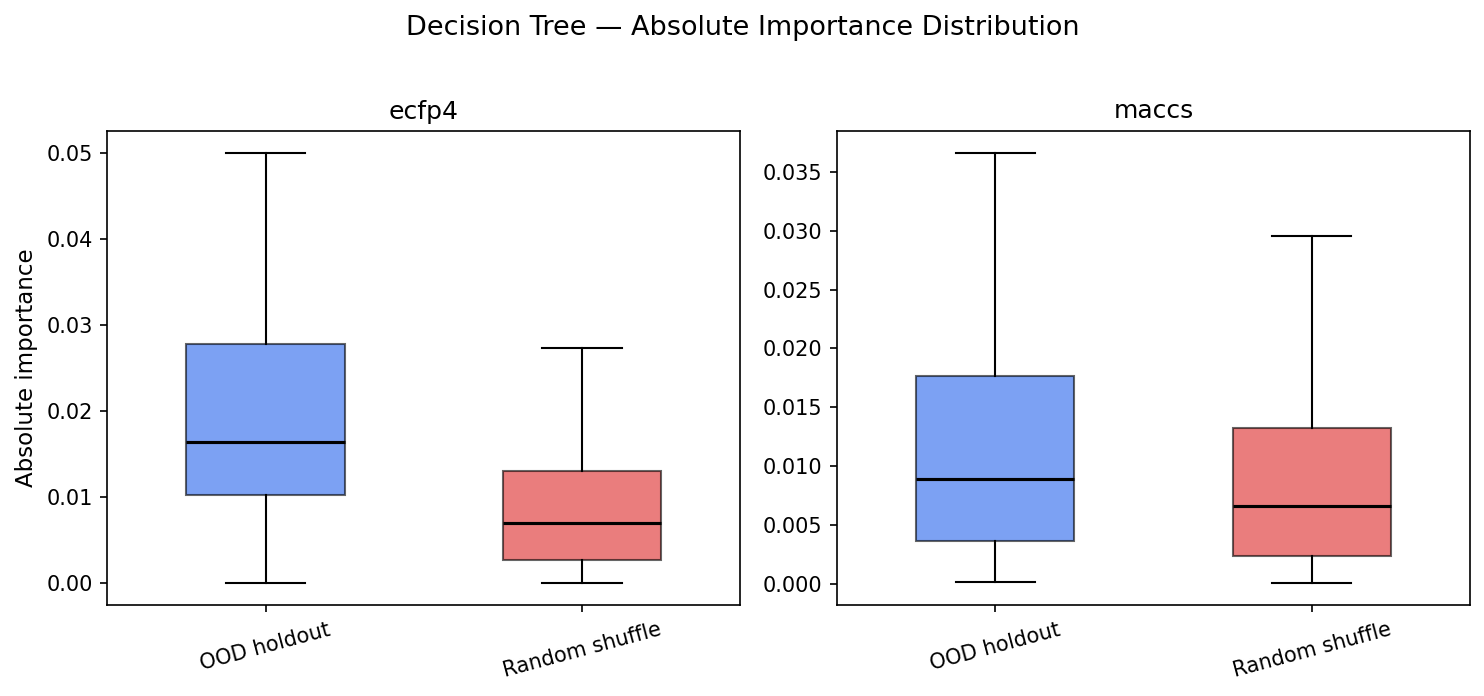

Saved: importance_distribution_logistic_regression.png


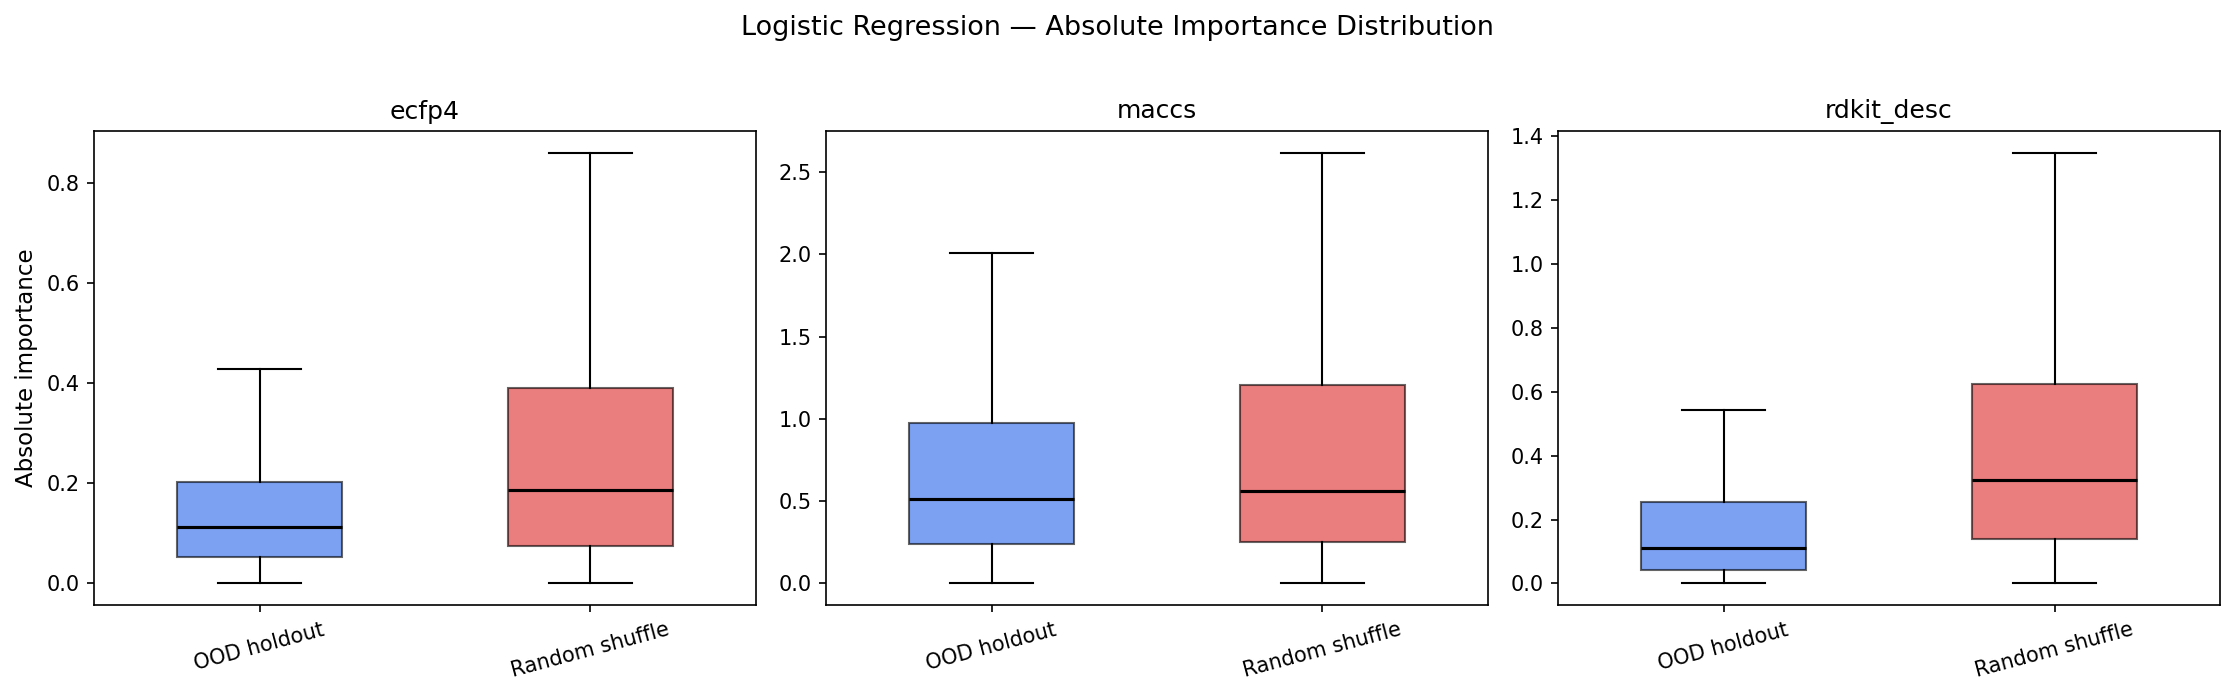

Saved: importance_distribution_svm_linear.png


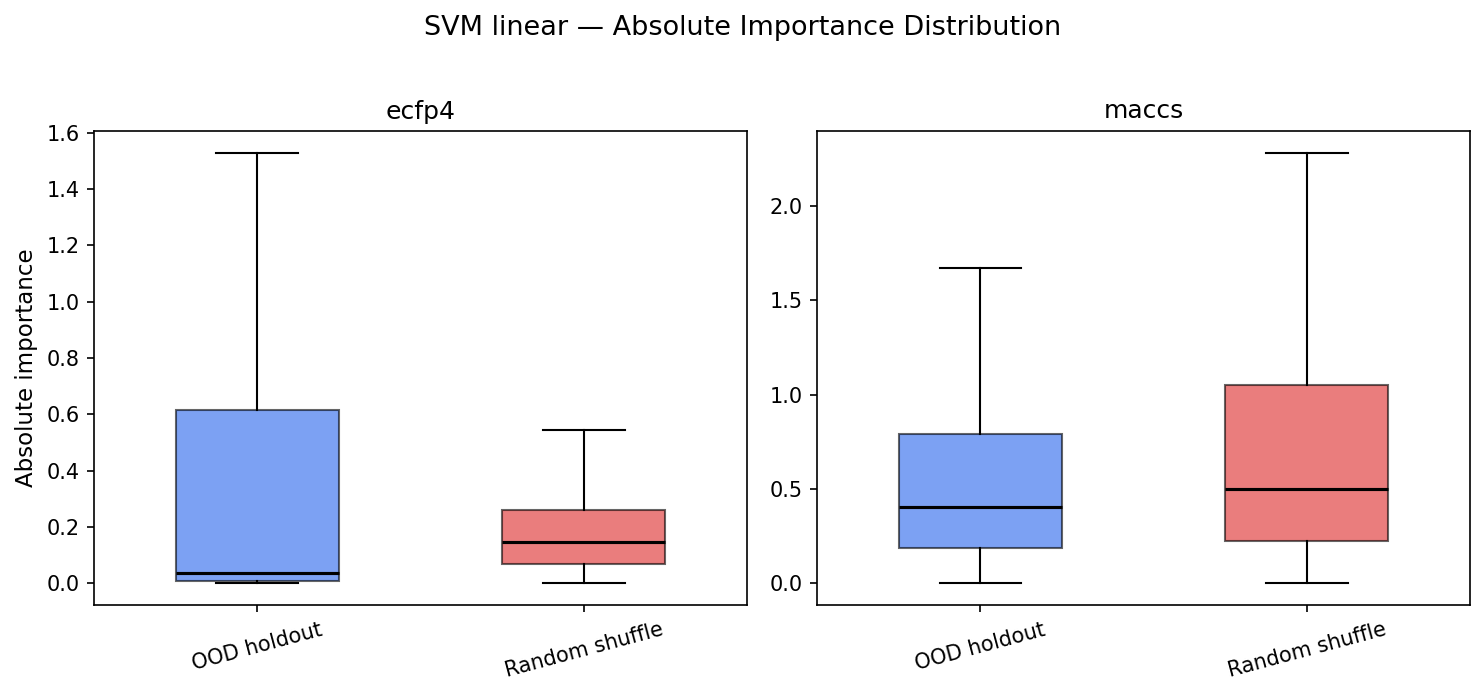

In [4]:
for model in MODELS:
    sub = fi_all[fi_all["model"] == model].copy()
    fps = sorted(sub["fingerprint"].unique())
    n_fp = len(fps)
 
    fig, axes = plt.subplots(1, n_fp, figsize=(5 * n_fp, 4.5), sharey=False, squeeze=False)
    fig.suptitle(f"{model} — Absolute Importance Distribution", fontsize=13, y=1.02)
 
    for j, fp in enumerate(fps):
        ax = axes[0, j]
        fp_data = sub[sub["fingerprint"] == fp]
 
        # Filter to non-zero importance for readability
        fp_data = fp_data[fp_data["abs_importance"] > 0]
 
        box_data = []
        labels = []
        colors = []
 
        for protocol in PROTOCOL_ORDER:
            vals = fp_data.loc[fp_data["protocol"] == protocol, "abs_importance"].values
            if len(vals) > 0:
                box_data.append(vals)
                labels.append(protocol)
                colors.append(PROTOCOL_COLORS[protocol])
 
        if not box_data:
            ax.set_title(f"{fp}\n(no data)")
            continue
 
        bp = ax.boxplot(
            box_data, tick_labels=labels, patch_artist=True,
            showfliers=False, widths=0.5,
            medianprops=dict(color="black", linewidth=1.5),
        )
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
 
        ax.set_title(fp)
        ax.set_ylabel("Absolute importance" if j == 0 else "")
        ax.tick_params(axis="x", rotation=15)
 
    fig.tight_layout()
    fname = FIG_DIR / f"importance_distribution_{model.lower().replace(' ', '_')}.png"
    fig.savefig(fname)
    print(f"Saved: {fname.name}")
    plt.show()

# Top-k protocol overlap

 For each model × fingerprint × fold, how many of the top-k features are shared
between OOD holdout and random shuffle?

 High overlap → protocols use similar features.
 Low overlap → protocols rely on different signals.

Saved: topk_overlap_heatmap_decision_tree.png


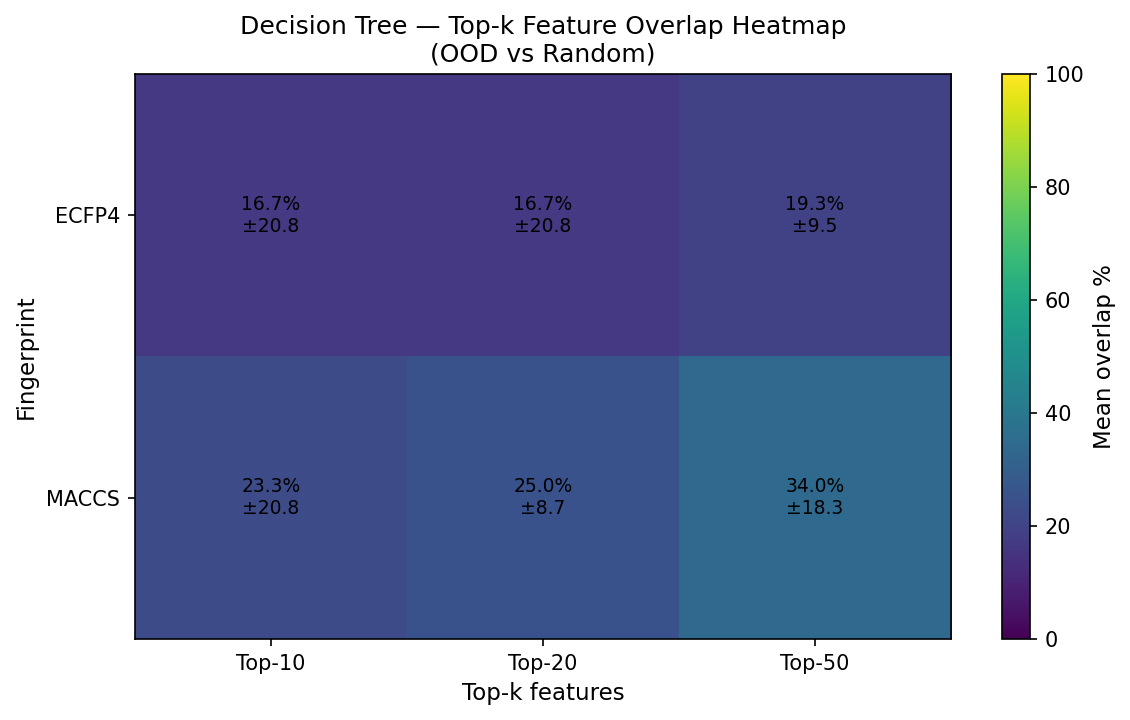

Saved: topk_overlap_heatmap_logistic_regression.png


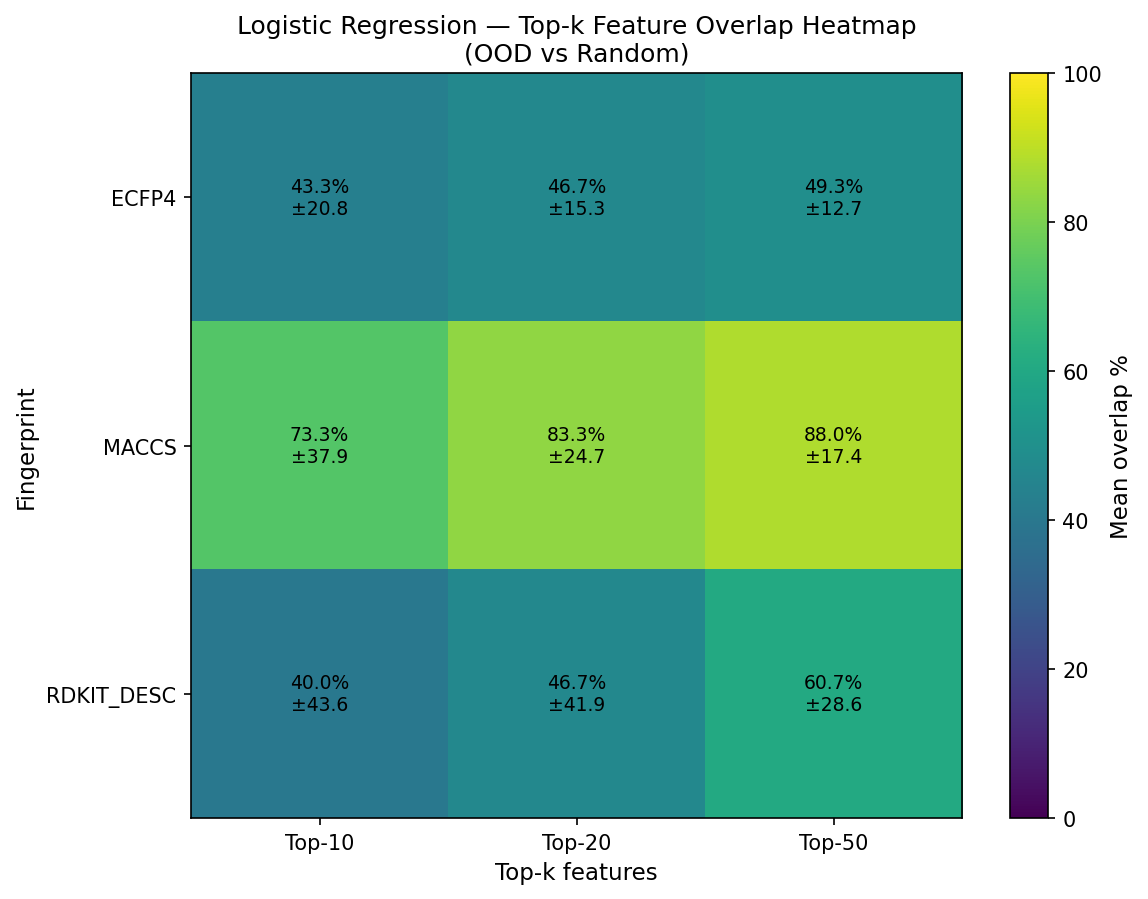

Saved: topk_overlap_heatmap_svm_linear.png


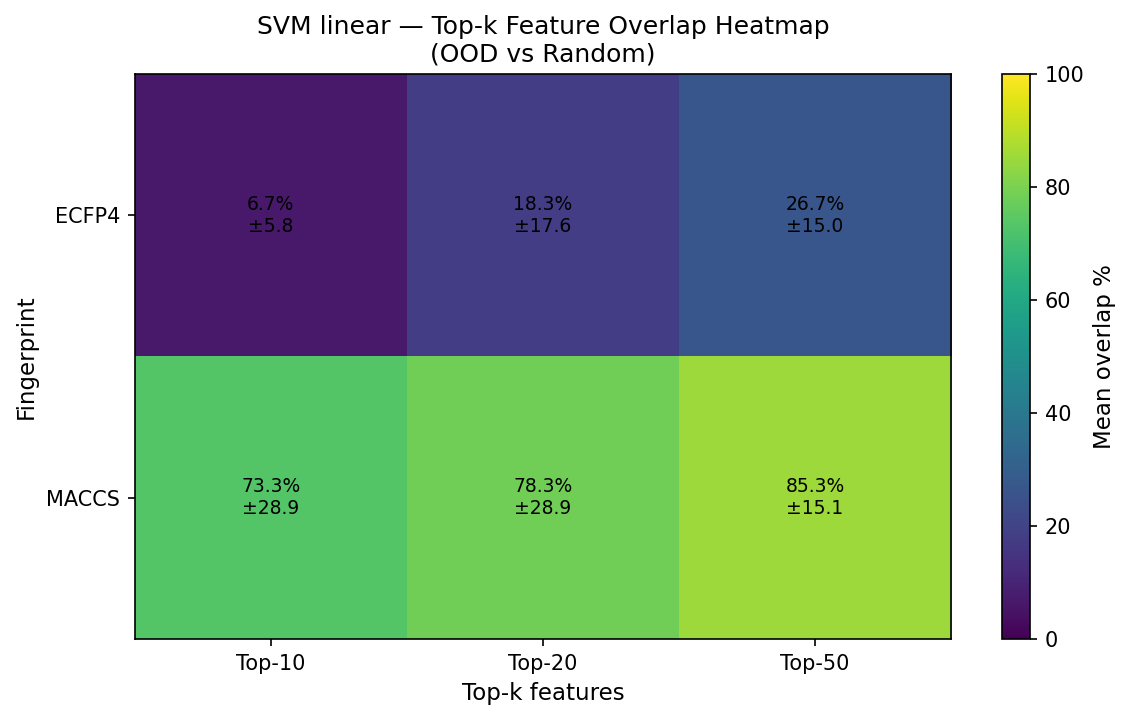

In [9]:
for model in MODELS:
    sub = overlap_protocol[overlap_protocol["model"] == model].copy()

    fps = sorted(sub["fingerprint"].unique())
    ks = sorted(sub["top_k"].unique())

    # mean/std overlap for each fingerprint x top-k
    agg = (
        sub.groupby(["fingerprint", "top_k"])["overlap_percent"]
        .agg(["mean", "std"])
        .reset_index()
    )

    mean_mat = np.full((len(fps), len(ks)), np.nan)
    std_mat = np.full((len(fps), len(ks)), np.nan)

    for i, fp in enumerate(fps):
        for j, k in enumerate(ks):
            row = agg[(agg["fingerprint"] == fp) & (agg["top_k"] == k)]
            if not row.empty:
                mean_mat[i, j] = row["mean"].iloc[0]
                std_mat[i, j] = row["std"].iloc[0]

    fig, ax = plt.subplots(figsize=(1.8 * len(ks) + 2.5, 1.2 * len(fps) + 2.5))

    im = ax.imshow(mean_mat, aspect="auto", vmin=0, vmax=100)

    ax.set_xticks(np.arange(len(ks)))
    ax.set_xticklabels([f"Top-{k}" for k in ks])

    ax.set_yticks(np.arange(len(fps)))
    ax.set_yticklabels([fp.upper() for fp in fps])

    ax.set_xlabel("Top-k features")
    ax.set_ylabel("Fingerprint")
    ax.set_title(f"{model} — Top-k Feature Overlap Heatmap\n(OOD vs Random)")

    # annotations: mean ± std
    for i in range(len(fps)):
        for j in range(len(ks)):
            val = mean_mat[i, j]
            std = std_mat[i, j]

            if not np.isnan(val):
                text = f"{val:.1f}%"
                if not np.isnan(std):
                    text += f"\n±{std:.1f}"

                ax.text(
                    j, i, text,
                    ha="center", va="center",
                    fontsize=9,
                    color="black"
                )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Mean overlap %")

    plt.tight_layout()
    fname = FIG_DIR / f"topk_overlap_heatmap_{model.lower().replace(' ', '_')}.png"
    fig.savefig(fname, dpi=300, bbox_inches="tight")
    print(f"Saved: {fname.name}")
    plt.show()

# Cumulative importance curves

 Features sorted by decreasing importance.
 A curve that rises steeply → importance concentrated on few features.
 A curve that rises slowly → importance distributed across many features.

 One panel per fingerprint, curves for each protocol × fold.

Saved: cumulative_importance_decision_tree.png


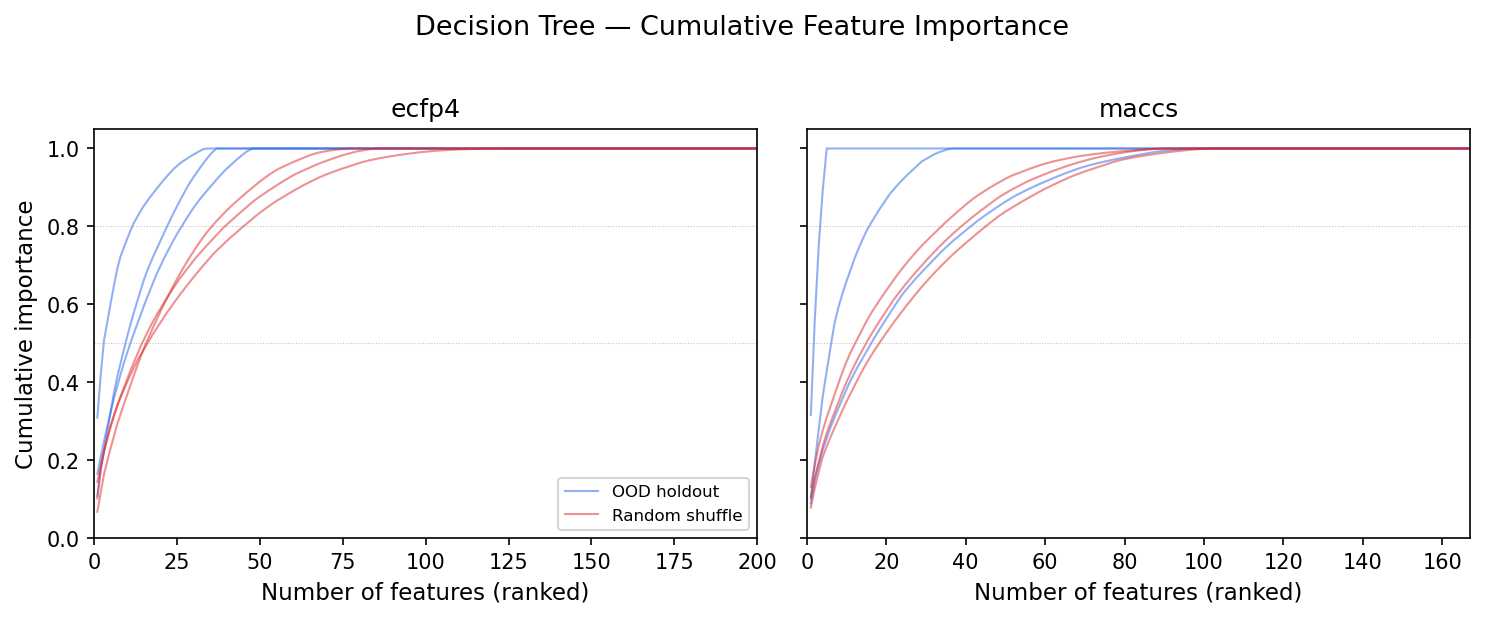

Saved: cumulative_importance_logistic_regression.png


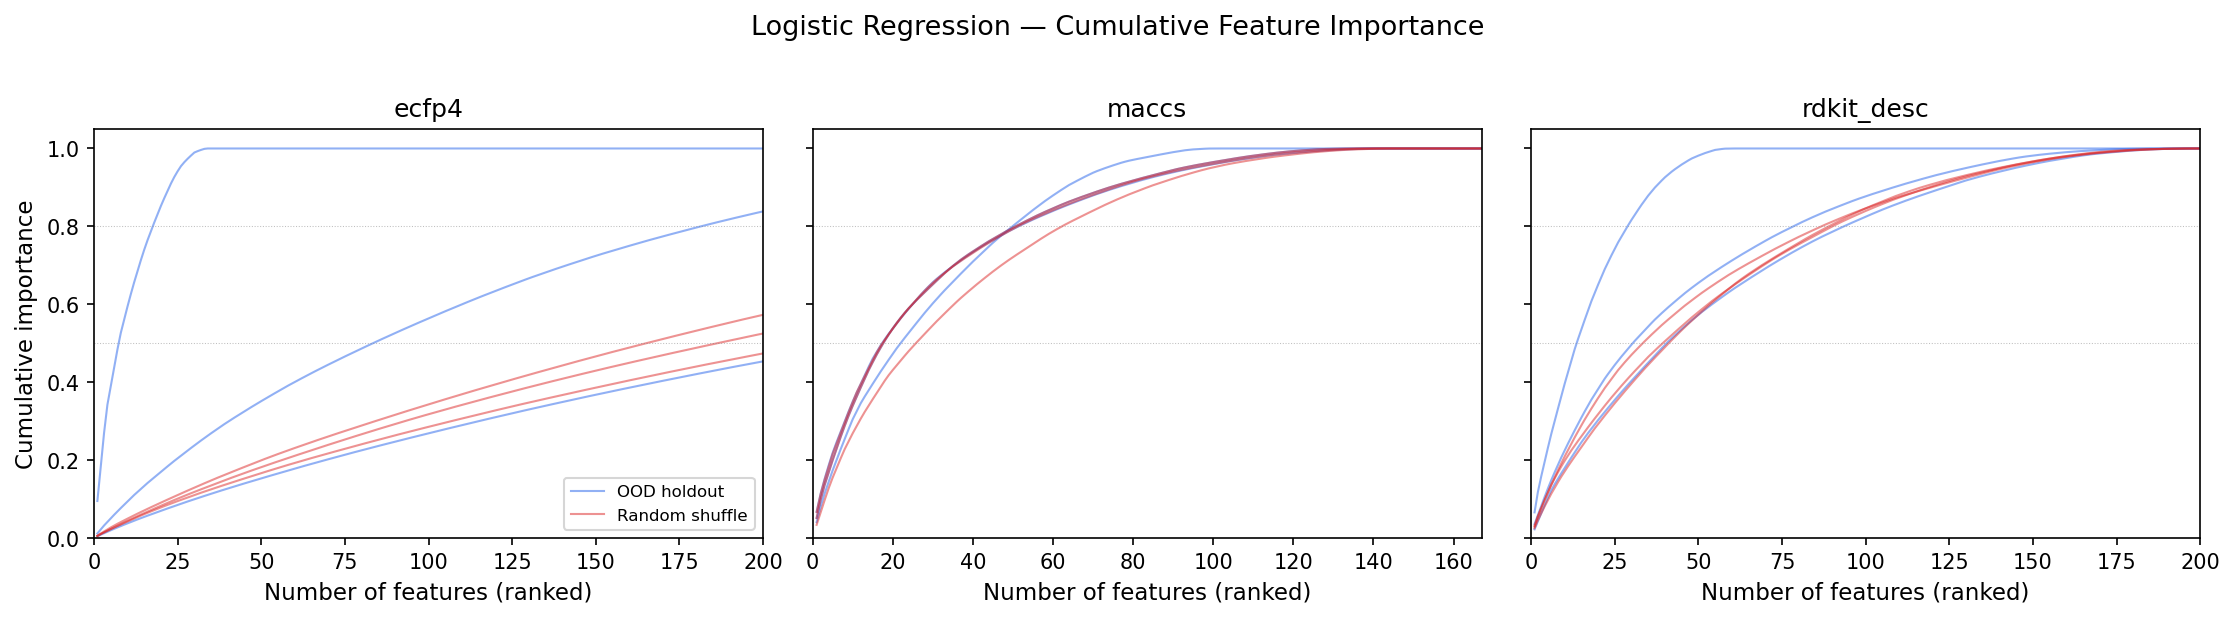

Saved: cumulative_importance_svm_linear.png


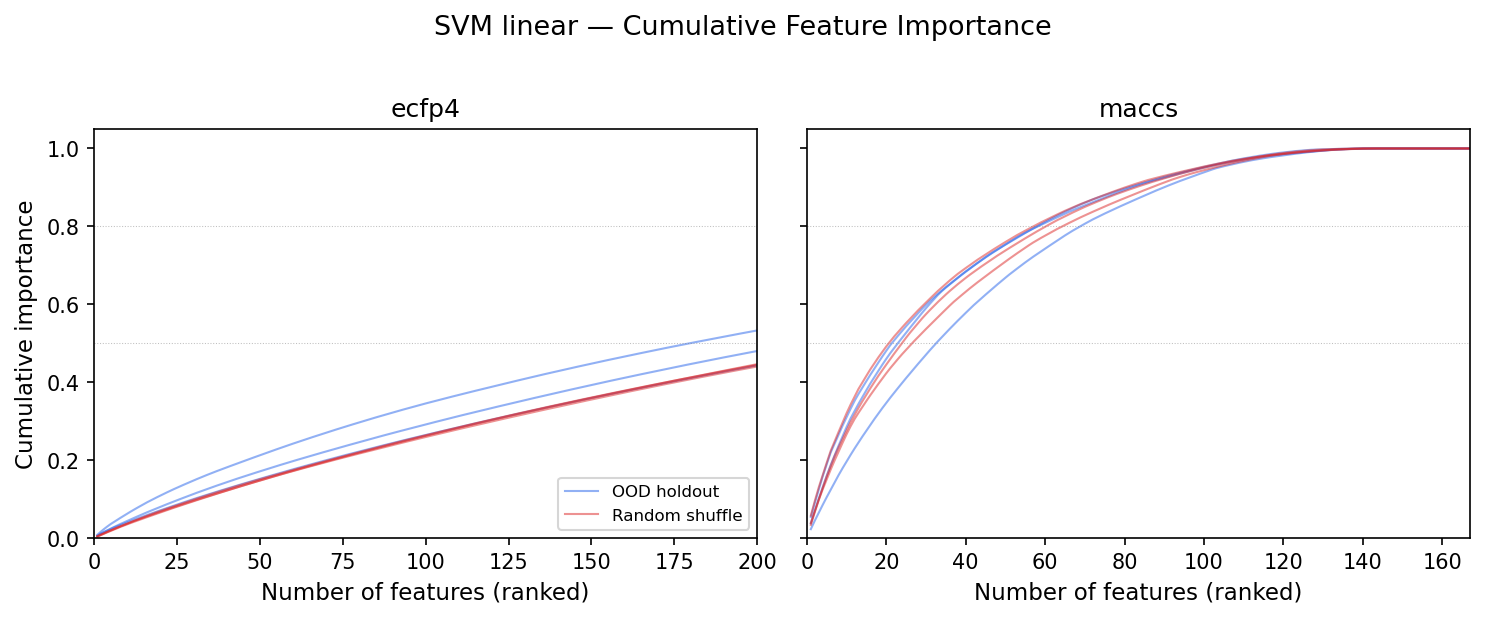

In [8]:
for model in MODELS:
    sub = fi_all[fi_all["model"] == model].copy()
    fps = sorted(sub["fingerprint"].unique())
    n_fp = len(fps)
 
    fig, axes = plt.subplots(1, n_fp, figsize=(5 * n_fp, 4), sharey=True, squeeze=False)
    fig.suptitle(f"{model} — Cumulative Feature Importance", fontsize=13, y=1.02)
 
    for j, fp in enumerate(fps):
        ax = axes[0, j]
        fp_sub = sub[sub["fingerprint"] == fp]
 
        for protocol in PROTOCOL_ORDER:
            color = PROTOCOL_COLORS[protocol]
 
            for fold in [1, 2, 3]:
                fold_sub = fp_sub[
                    (fp_sub["protocol"] == protocol) & (fp_sub["fold"] == fold)
                ].sort_values("rank")
 
                imp = fold_sub["importance"].fillna(0).values
                cumulative = np.cumsum(imp)
 
                ax.plot(
                    range(1, len(cumulative) + 1), cumulative,
                    color=color, alpha=0.5, linewidth=1.0,
                    label=f"{protocol}" if fold == 1 else None,
                )
 
        ax.set_title(fp)
        ax.set_xlabel("Number of features (ranked)")
        ax.set_ylabel("Cumulative importance" if j == 0 else "")
        ax.set_ylim(0, 1.05)
        ax.axhline(0.8, color="gray", linestyle=":", linewidth=0.5, alpha=0.5)
        ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.5, alpha=0.5)
 
        # Zoom x-axis to first 200 features for readability
        n_features = len(fp_sub["feature_idx"].unique())
        ax.set_xlim(0, min(200, n_features))
 
    if n_fp > 0:
        axes[0, 0].legend(loc="lower right", fontsize=8)
 
    fig.tight_layout()
    fname = FIG_DIR / f"cumulative_importance_{model.lower().replace(' ', '_')}.png"
    fig.savefig(fname)
    print(f"Saved: {fname.name}")
    plt.show()

# Decision Tree — Minimum depth distribution

 For Decision Tree models, each feature used in a split has a "minimum depth":
 the shallowest level at which that feature appears.

 Features at depth 0 (root) are the most globally influential.
 This answers: *"come cambia depth per ogni feature, depth minima per ogni feature"*

/tmp/ipykernel_3481087/3249589454.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3481087/3249589454.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: minimum_depth_decision_tree.png


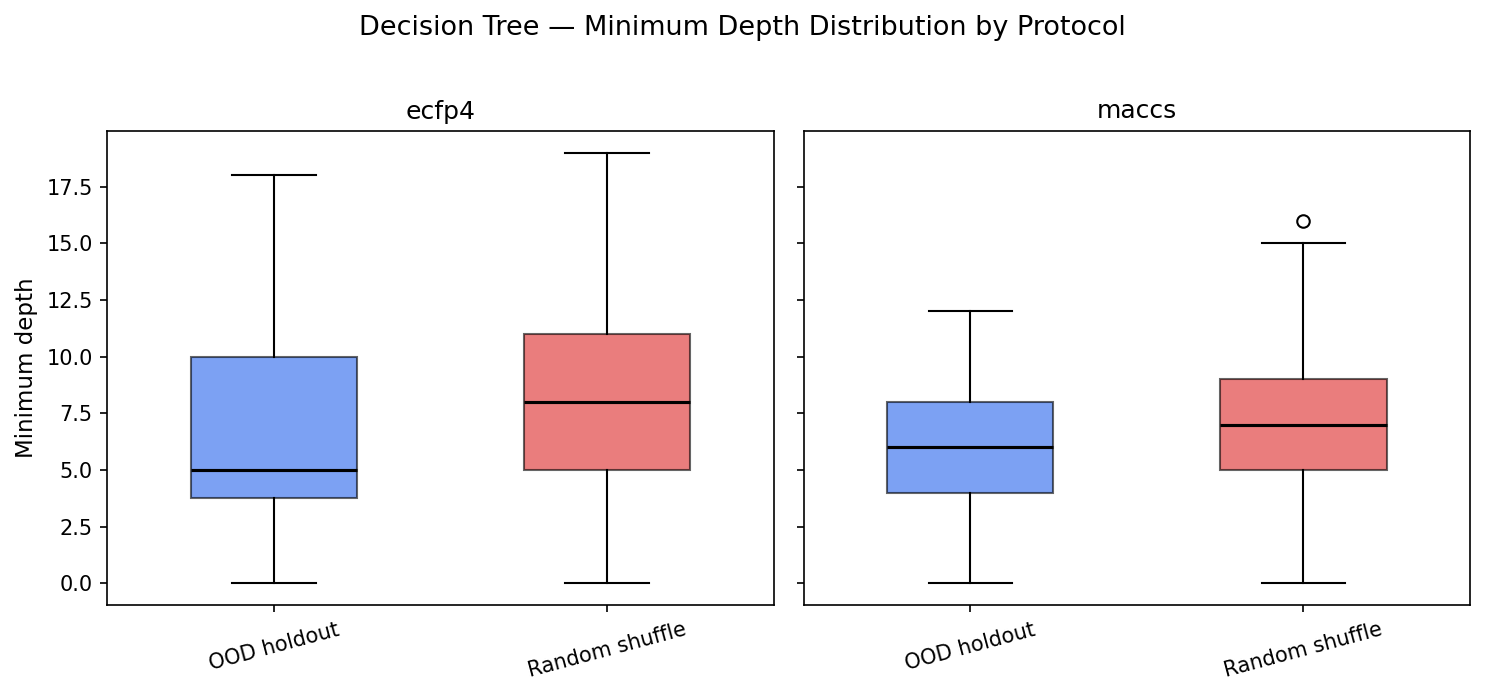

In [10]:
dt_sub = fi_all[
    (fi_all["model"] == "Decision Tree")
    & (fi_all.get("minimum_depth", pd.Series(dtype=float)).notna()
       if "minimum_depth" in fi_all.columns else False)
].copy()
 
if len(dt_sub) > 0 and "minimum_depth" in dt_sub.columns:
    dt_sub = dt_sub.dropna(subset=["minimum_depth"])
    fps = sorted(dt_sub["fingerprint"].unique())
    n_fp = len(fps)
 
    fig, axes = plt.subplots(1, n_fp, figsize=(5 * n_fp, 4.5), sharey=True, squeeze=False)
    fig.suptitle("Decision Tree — Minimum Depth Distribution by Protocol", fontsize=13, y=1.02)
 
    for j, fp in enumerate(fps):
        ax = axes[0, j]
        fp_data = dt_sub[dt_sub["fingerprint"] == fp]
 
        box_data = []
        labels = []
        colors = []
 
        for protocol in PROTOCOL_ORDER:
            vals = fp_data.loc[fp_data["protocol"] == protocol, "minimum_depth"].values
            if len(vals) > 0:
                box_data.append(vals)
                labels.append(protocol)
                colors.append(PROTOCOL_COLORS[protocol])
 
        if box_data:
            bp = ax.boxplot(
                box_data, labels=labels, patch_artist=True,
                showfliers=True, widths=0.5,
                medianprops=dict(color="black", linewidth=1.5),
            )
            for patch, color in zip(bp["boxes"], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.6)
 
        ax.set_title(fp)
        ax.set_ylabel("Minimum depth" if j == 0 else "")
        ax.invert_yaxis()  # depth 0 (root) at top
        ax.tick_params(axis="x", rotation=15)
 
    fig.tight_layout()
    fname = FIG_DIR / "minimum_depth_decision_tree.png"
    fig.savefig(fname)
    print(f"Saved: {fname.name}")
    plt.show()
else:
    print("No minimum_depth data available for Decision Tree. Skipping.")

# Intra-protocol feature stability heatmaps

 How stable are the top-k features across outer folds within the same protocol?

 Each heatmap shows overlap (%) for fold pairs × k values.
 One heatmap per model × protocol.

/tmp/ipykernel_3481087/4129469326.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: stability_heatmap_decision_tree_ecfp4.png


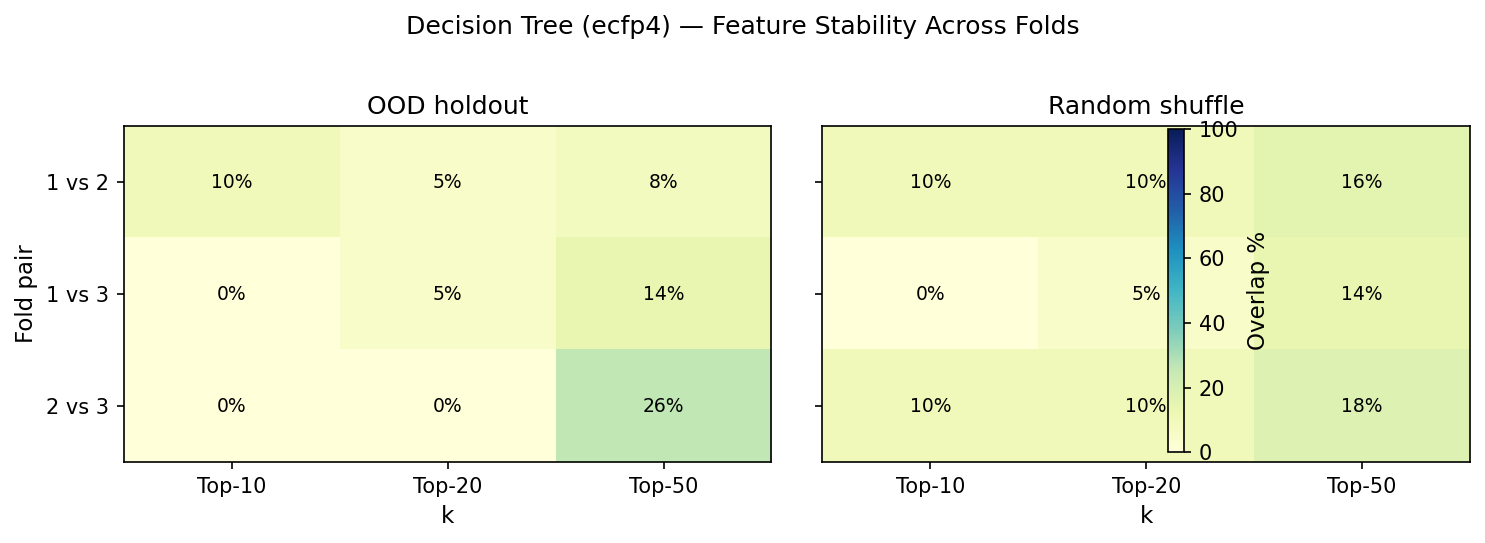

/tmp/ipykernel_3481087/4129469326.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: stability_heatmap_decision_tree_maccs.png


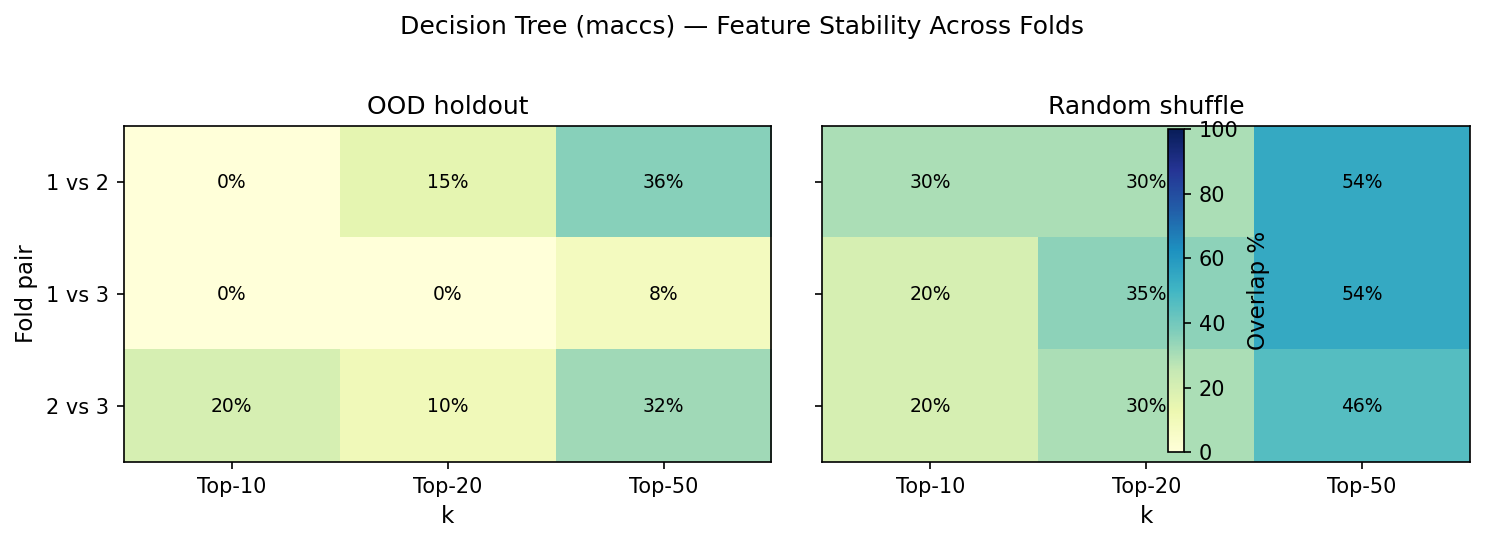

/tmp/ipykernel_3481087/4129469326.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: stability_heatmap_logistic_regression_ecfp4.png


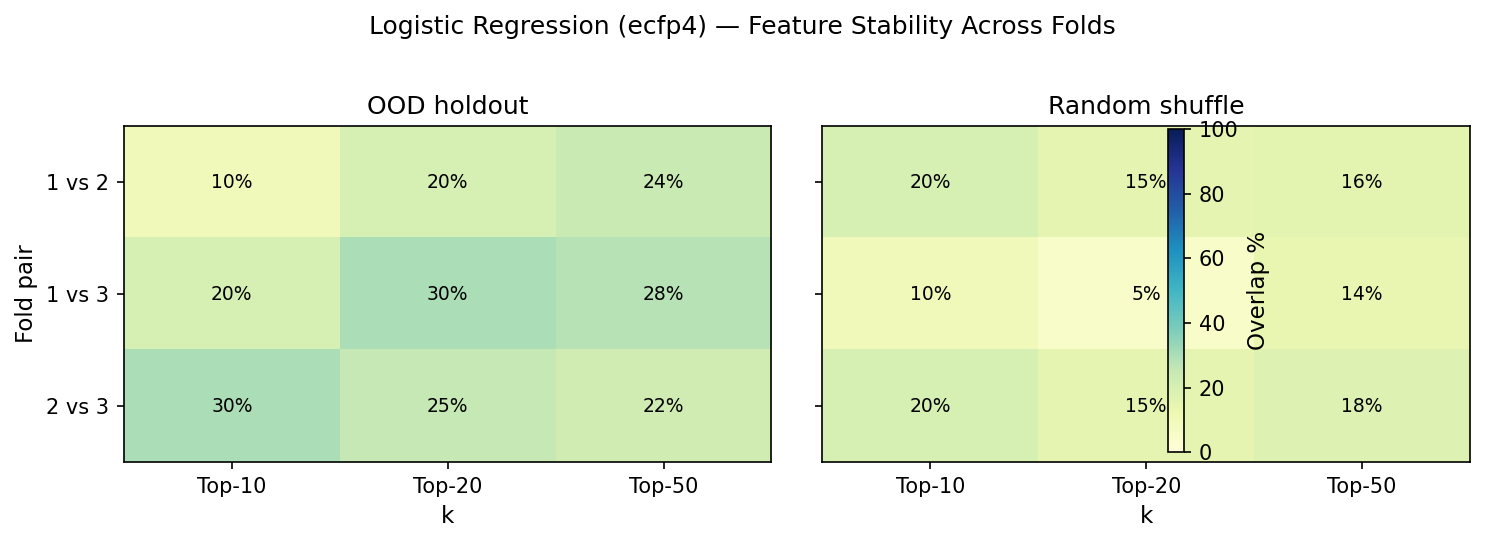

/tmp/ipykernel_3481087/4129469326.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: stability_heatmap_logistic_regression_maccs.png


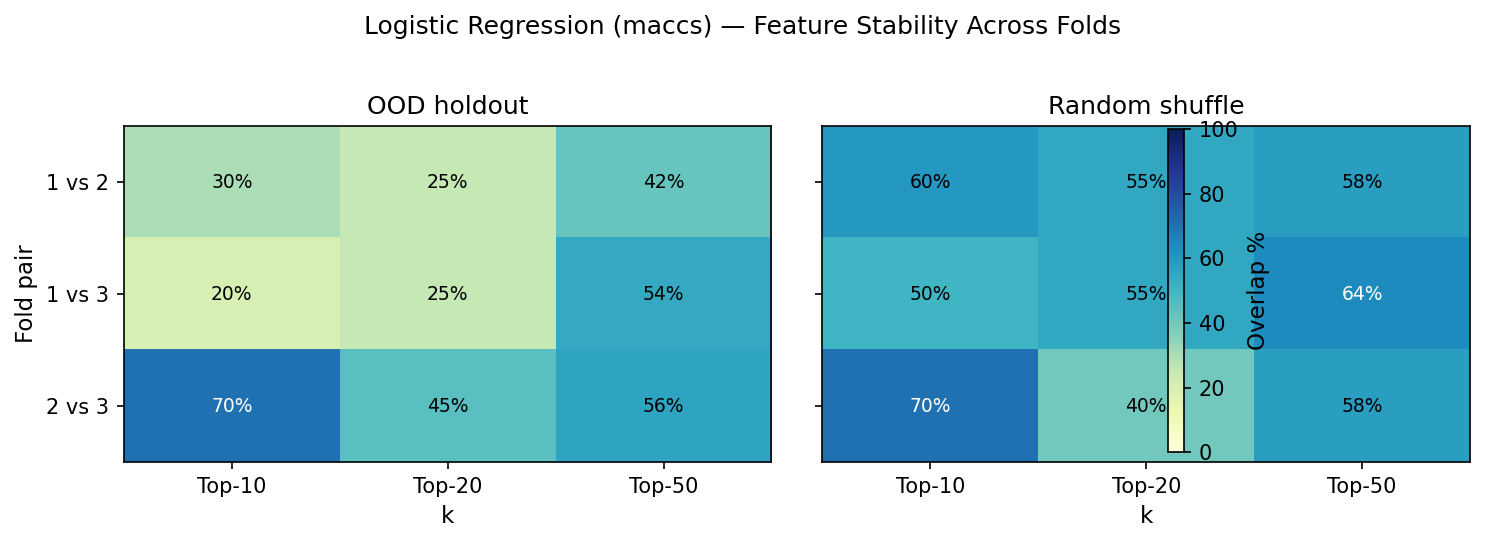

/tmp/ipykernel_3481087/4129469326.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: stability_heatmap_logistic_regression_rdkit_desc.png


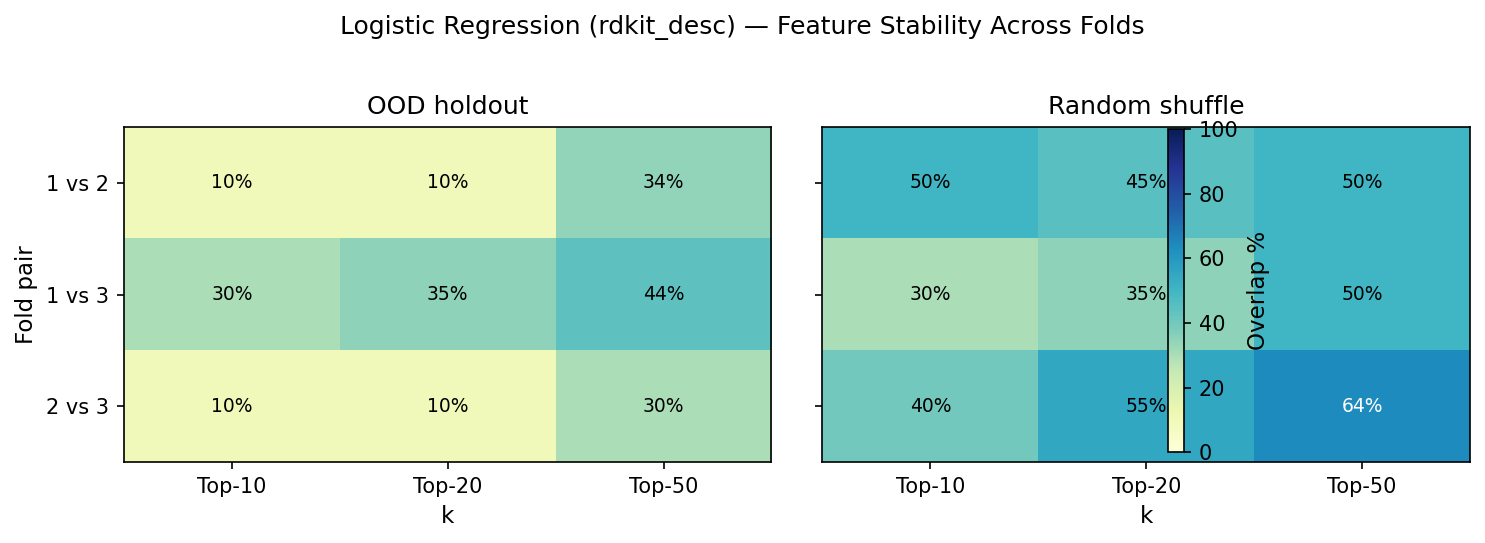

/tmp/ipykernel_3481087/4129469326.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: stability_heatmap_svm_linear_ecfp4.png


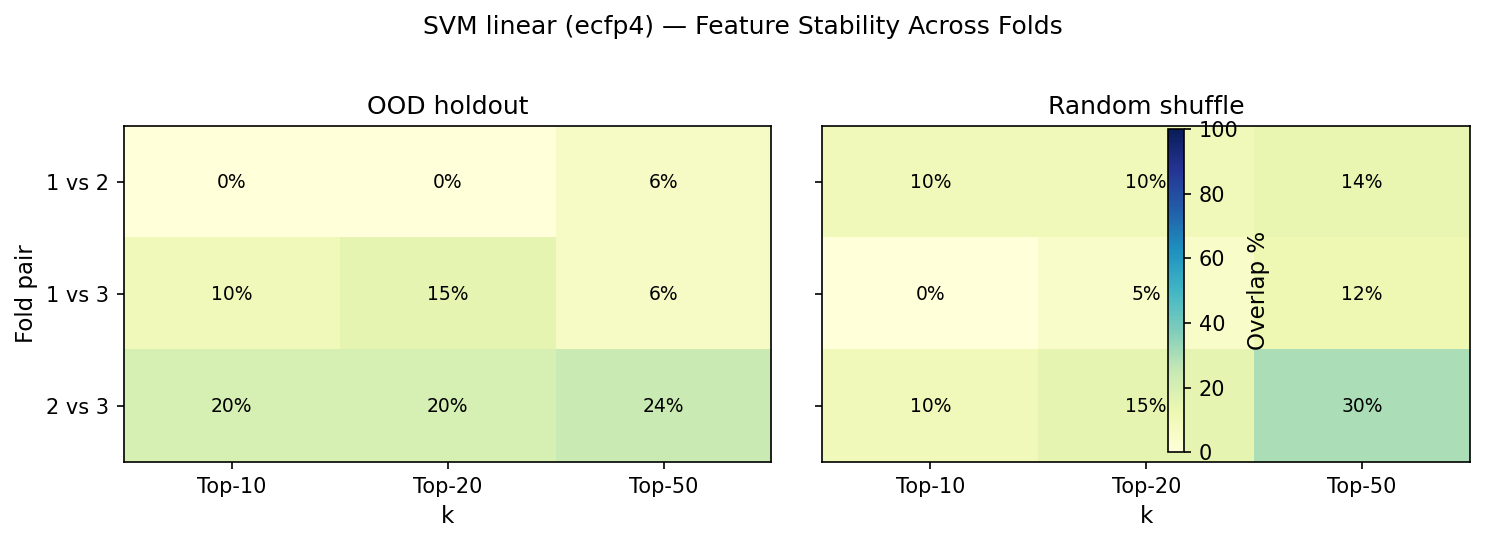

/tmp/ipykernel_3481087/4129469326.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: stability_heatmap_svm_linear_maccs.png


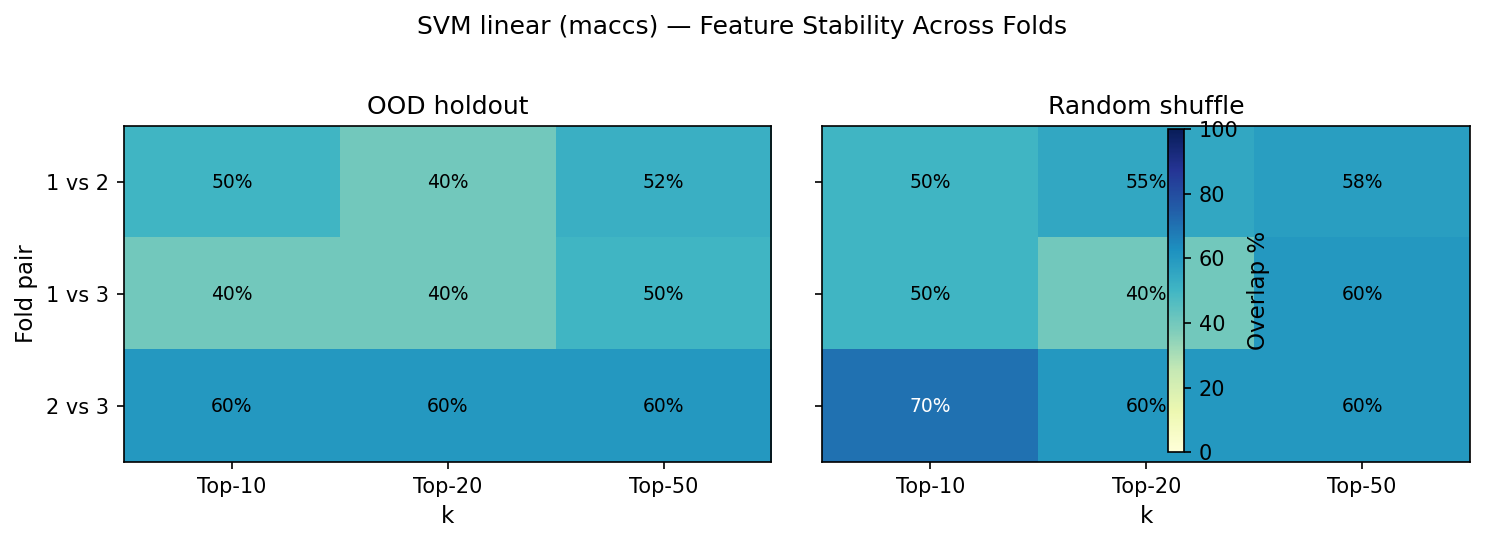

In [11]:
for model in MODELS:
    model_stab = stability[stability["model"] == model]
    fps = sorted(model_stab["fingerprint"].unique())
 
    for fp in fps:
        fp_stab = model_stab[model_stab["fingerprint"] == fp]
 
        if len(fp_stab) == 0:
            continue
 
        fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
        fig.suptitle(f"{model} ({fp}) — Feature Stability Across Folds", fontsize=12, y=1.02)
 
        for i, protocol in enumerate(PROTOCOL_ORDER):
            ax = axes[i]
            p_sub = fp_stab[fp_stab["protocol"] == protocol]
 
            if len(p_sub) == 0:
                ax.set_title(f"{protocol}\n(no data)")
                continue
 
            pivot = p_sub.pivot_table(
                index="fold_pair", columns="top_k", values="overlap_percent",
            )
 
            im = ax.imshow(pivot.values, cmap="YlGnBu", vmin=0, vmax=100, aspect="auto")
 
            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels([f"Top-{k}" for k in pivot.columns])
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels(pivot.index)
            ax.set_title(protocol)
            ax.set_xlabel("k")
            if i == 0:
                ax.set_ylabel("Fold pair")
 
            # Annotate cells
            for row_idx in range(len(pivot.index)):
                for col_idx in range(len(pivot.columns)):
                    val = pivot.values[row_idx, col_idx]
                    text_color = "white" if val > 60 else "black"
                    ax.text(col_idx, row_idx, f"{val:.0f}%",
                            ha="center", va="center", fontsize=9, color=text_color)
 
        fig.colorbar(im, ax=axes, label="Overlap %", shrink=0.8)
        fig.tight_layout()
 
        fname = FIG_DIR / f"stability_heatmap_{model.lower().replace(' ', '_')}_{fp}.png"
        fig.savefig(fname)
        print(f"Saved: {fname.name}")
        plt.show()
 

# Local feature contributions

 For selected test molecules, show which features push the prediction
 toward active (positive contribution) or inactive (negative contribution).

 Each subplot shows one molecule × one protocol, with horizontal bars for
 the top contributing features.

Saved: local_logistic_regression_ecfp4_fold1_both_correct.png


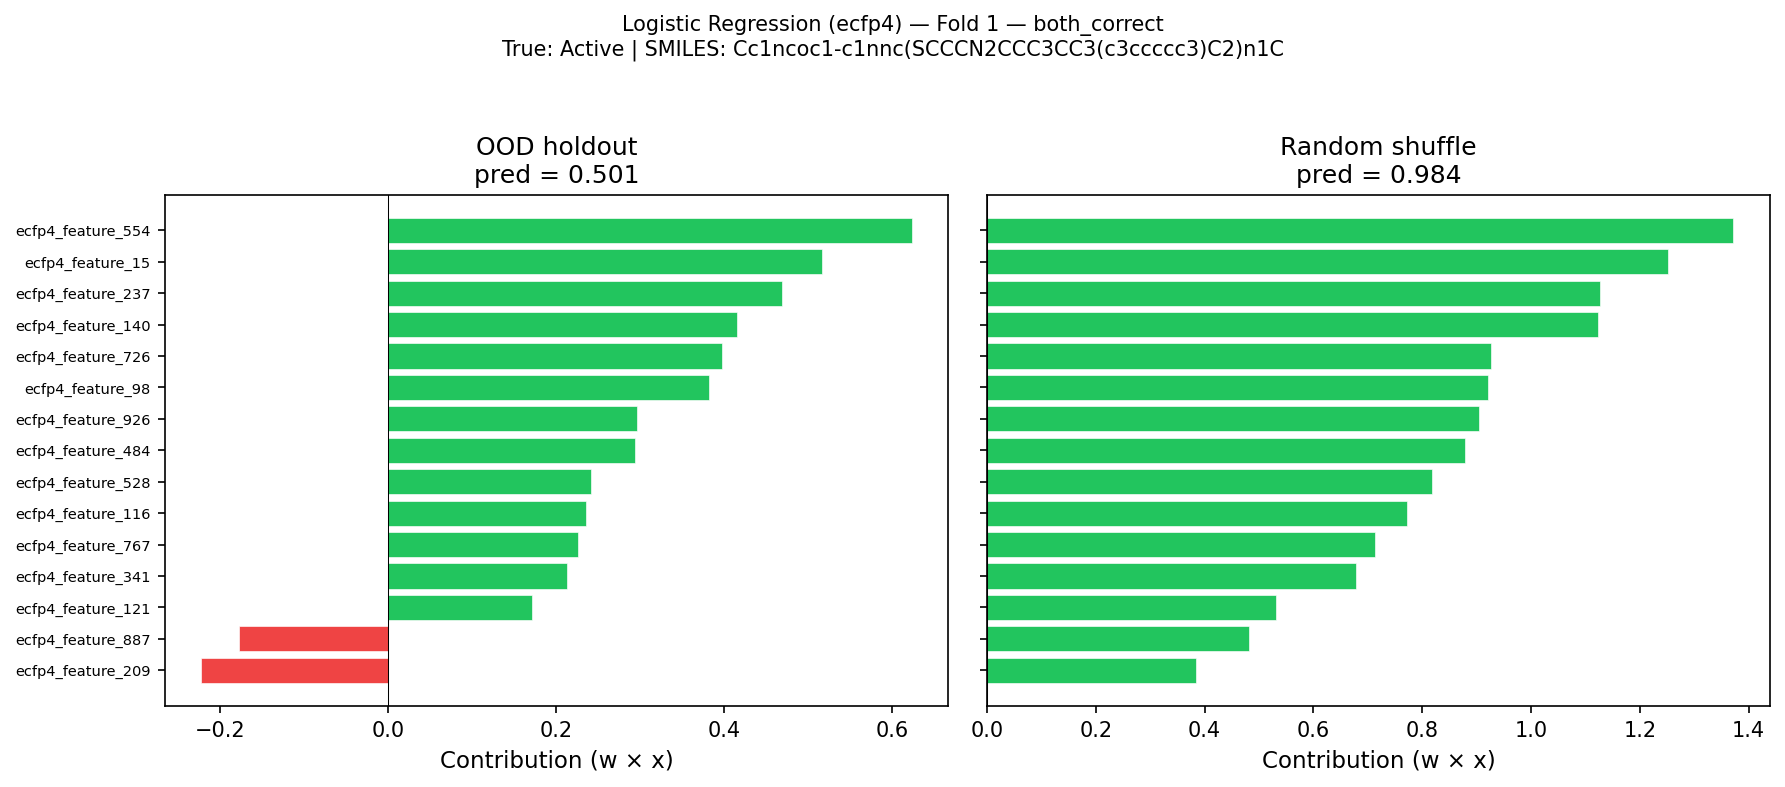

Saved: local_logistic_regression_ecfp4_fold1_both_wrong.png


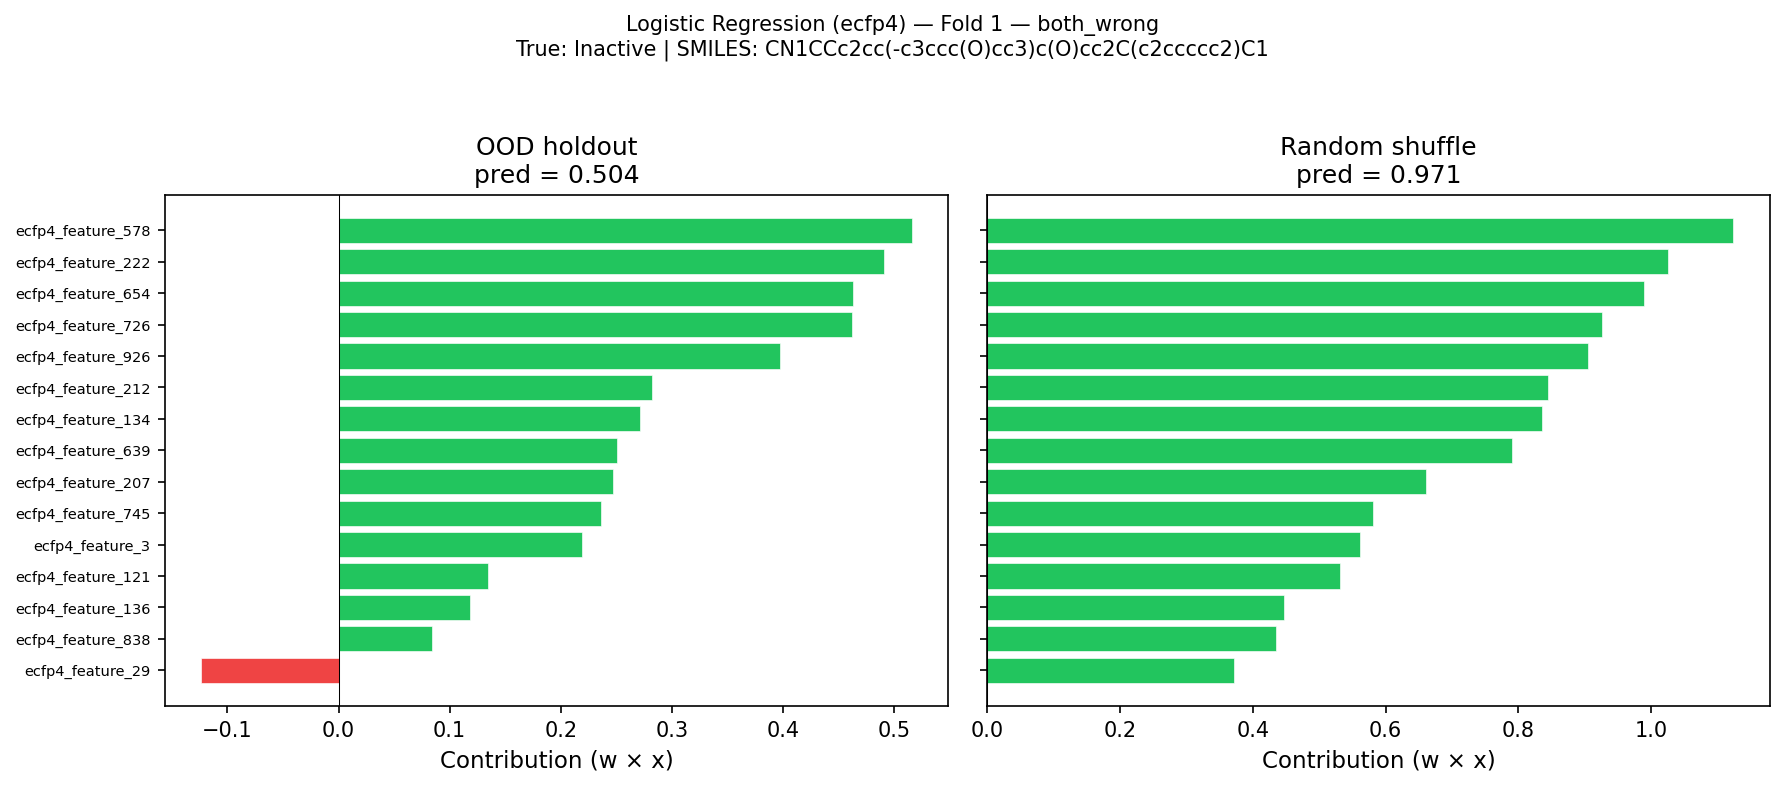

Saved: local_logistic_regression_ecfp4_fold1_ood_correct_random_wrong.png


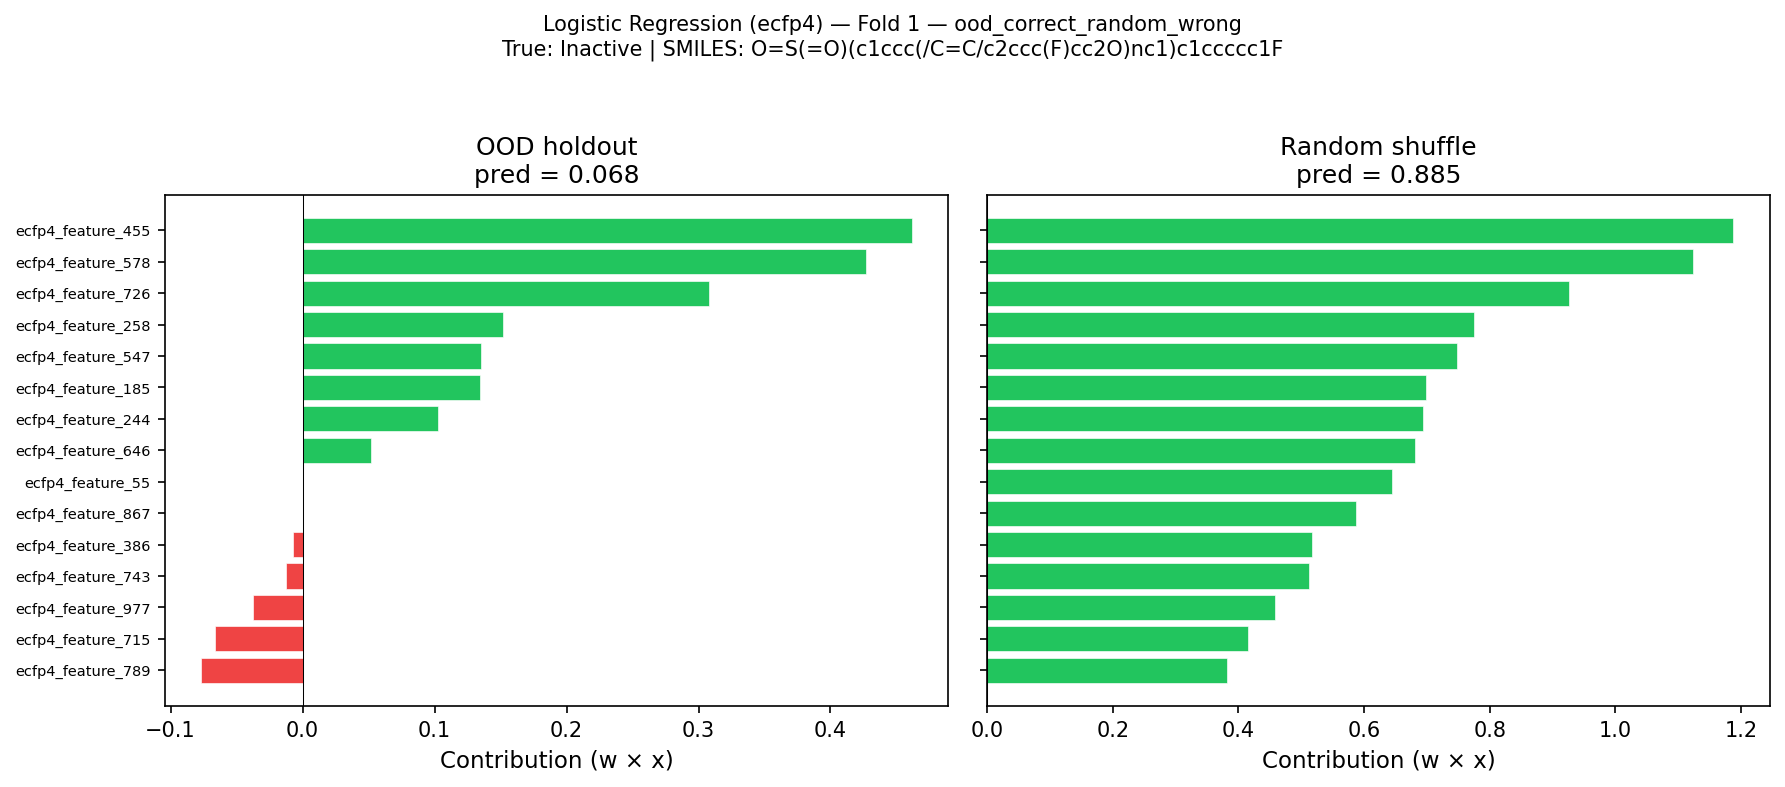

Saved: local_logistic_regression_ecfp4_fold1_ood_wrong_random_correct.png


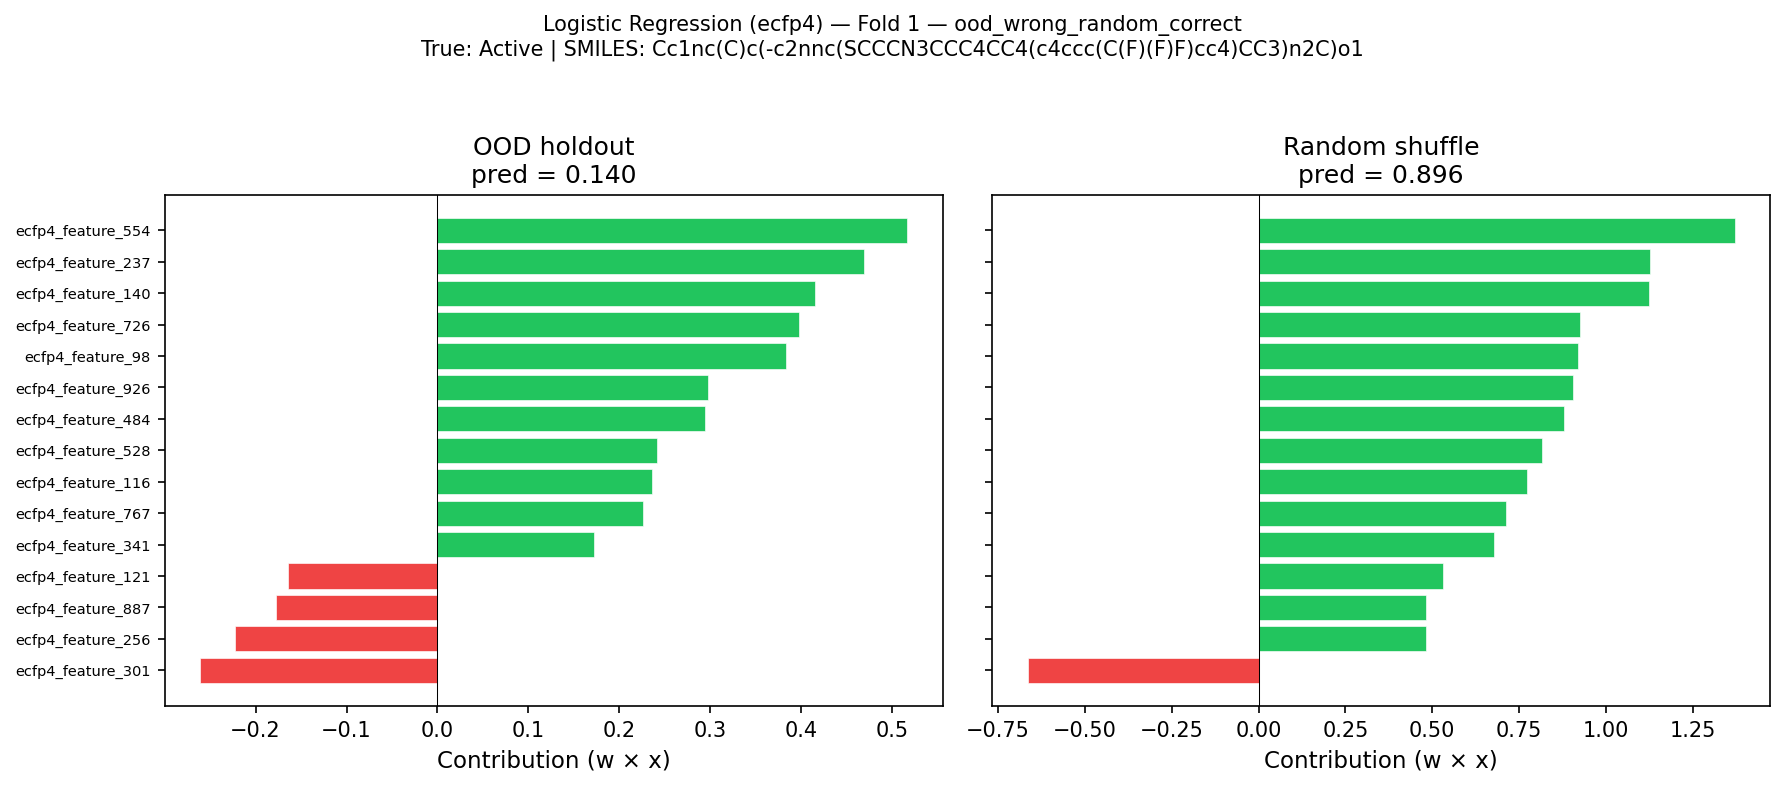

Saved: local_logistic_regression_ecfp4_fold2_both_correct.png


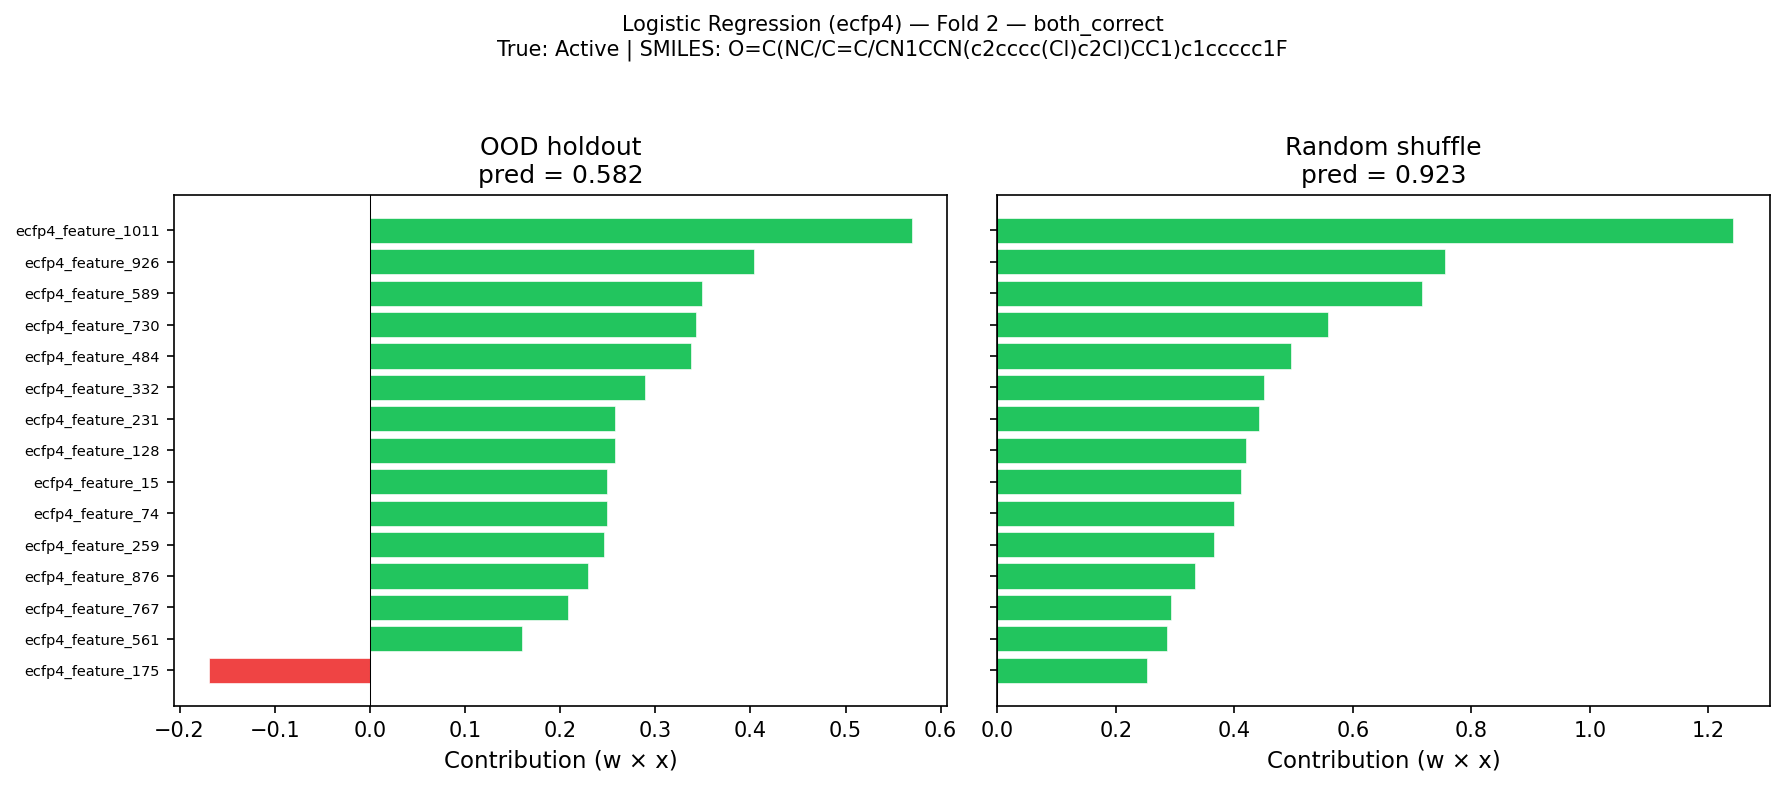

Saved: local_logistic_regression_ecfp4_fold2_both_wrong.png


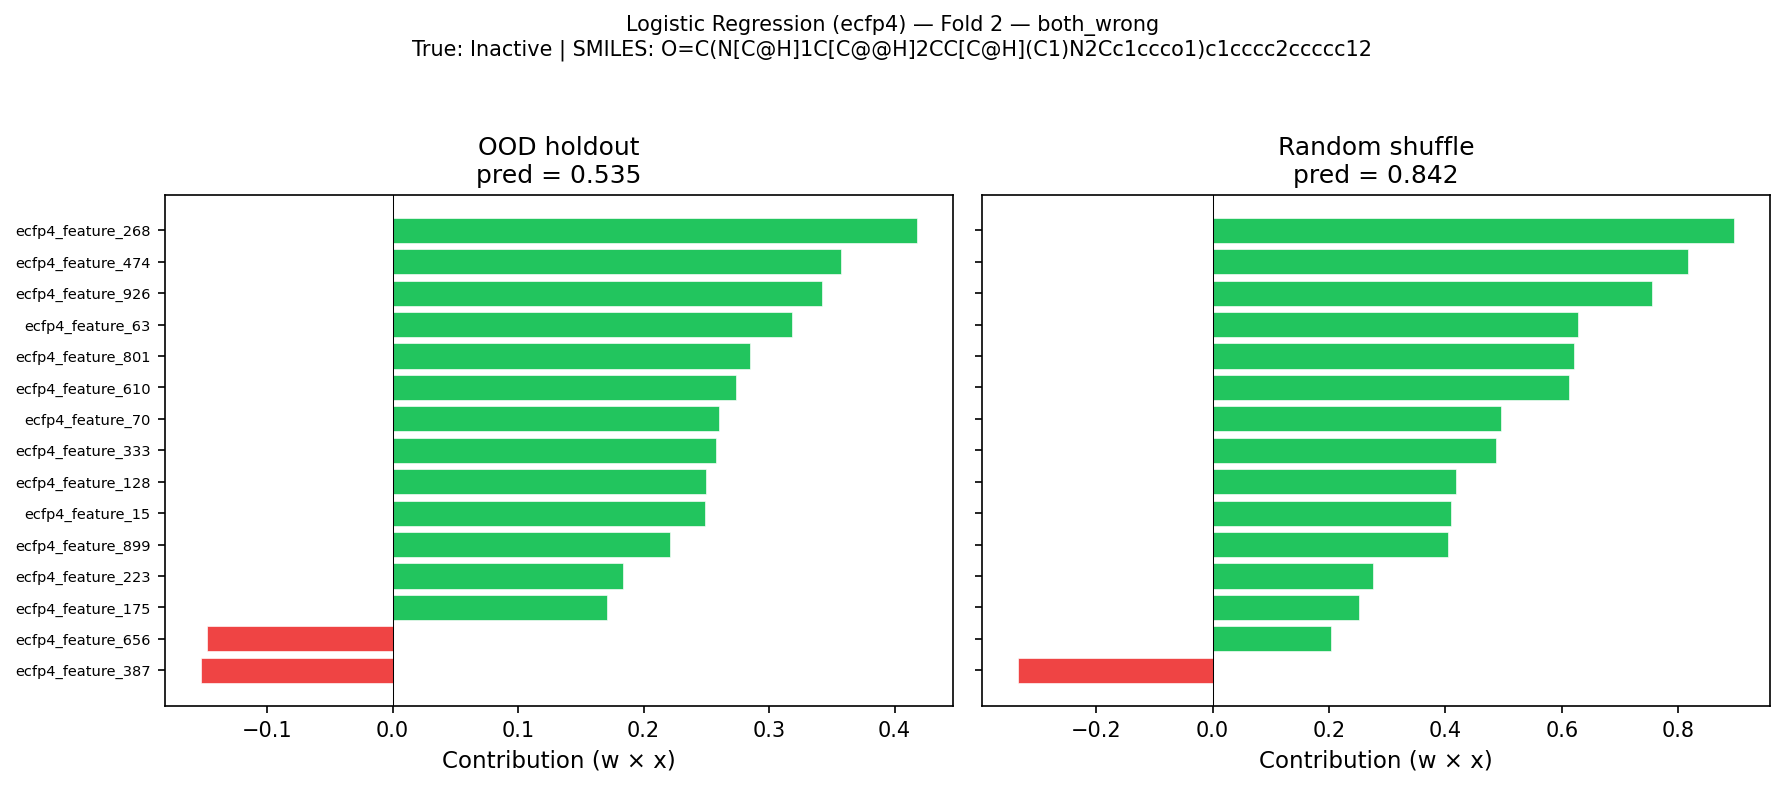

Saved: local_logistic_regression_ecfp4_fold2_ood_correct_random_wrong.png


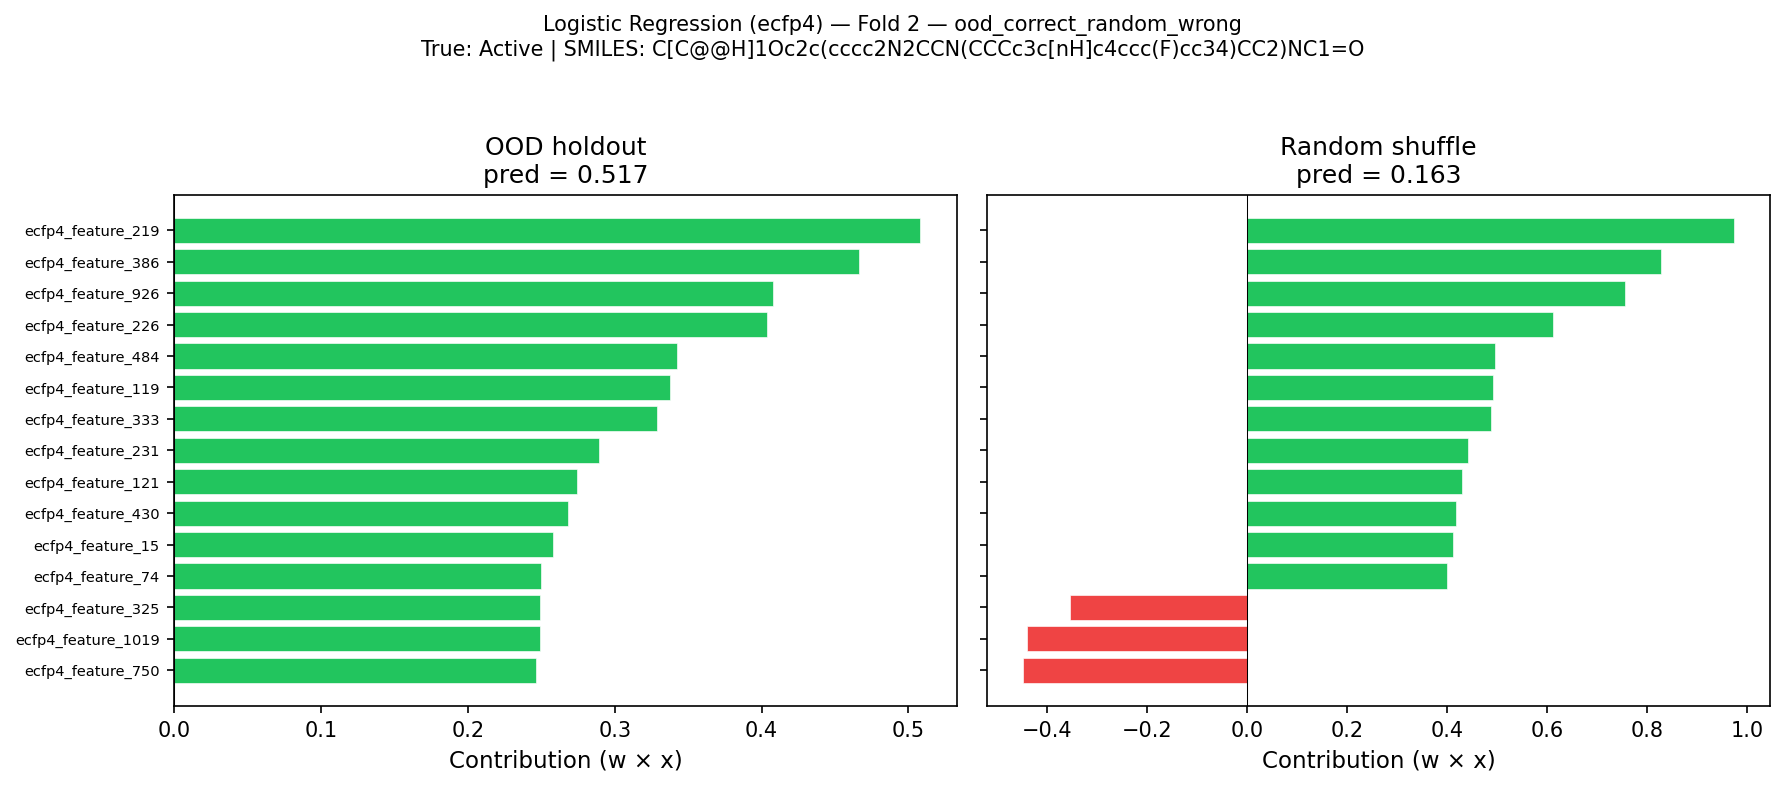

Saved: local_logistic_regression_ecfp4_fold2_ood_wrong_random_correct.png


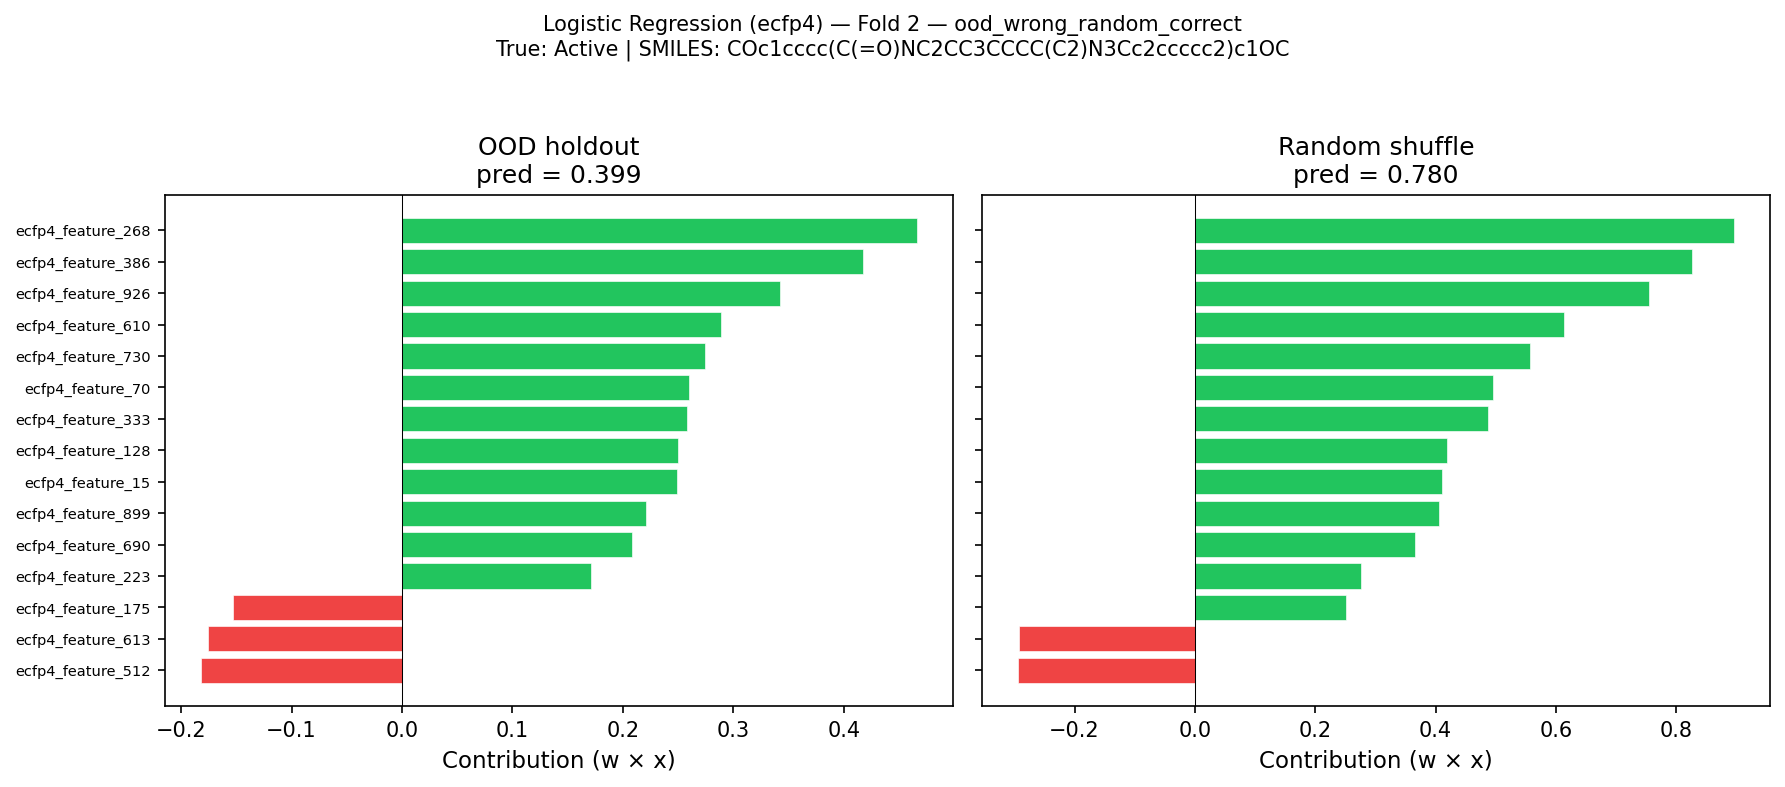

In [12]:
if len(local_contributions) == 0:
    print("No local contributions available. Skipping.")
else:
    # Group by (model, fingerprint, fold, smiles) to show OOD vs random side by side
    group_keys = local_contributions.groupby(
        ["model", "fingerprint", "fold", "smiles"]
    ).ngroups
 
    unique_molecules = (
        local_contributions
        .drop_duplicates(subset=["model", "fingerprint", "fold", "smiles", "category"])
        .sort_values(["model", "fingerprint", "fold", "category"])
    )
 
    # Limit to a few representative molecules
    shown = set()
 
    for _, mol_row in unique_molecules.iterrows():
        mol_key = (mol_row["model"], mol_row["fingerprint"], mol_row["smiles"])
        if mol_key in shown:
            continue
 
        model = mol_row["model"]
        fp = mol_row["fingerprint"]
        fold = mol_row["fold"]
        smiles = mol_row["smiles"]
        category = mol_row["category"]
        true_label = mol_row["true_label"]
 
        # Get contributions for both protocols
        mol_data = local_contributions[
            (local_contributions["model"] == model)
            & (local_contributions["fingerprint"] == fp)
            & (local_contributions["fold"] == fold)
            & (local_contributions["smiles"] == smiles)
        ]
 
        protocols_available = mol_data["protocol"].unique()
        if len(protocols_available) < 2:
            continue
 
        fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
        fig.suptitle(
            f"{model} ({fp}) — Fold {fold} — {category}\n"
            f"True: {'Active' if true_label else 'Inactive'} | "
            f"SMILES: {smiles[:60]}{'...' if len(smiles) > 60 else ''}",
            fontsize=10, y=1.04,
        )
 
        for i, protocol in enumerate(PROTOCOL_ORDER):
            ax = axes[i]
            p_data = mol_data[mol_data["protocol"] == protocol].copy()
 
            if len(p_data) == 0:
                ax.set_title(f"{protocol}\n(no data)")
                continue
 
            # Sort by contribution (not abs) for visual clarity
            p_data = p_data.sort_values("contribution", ascending=True).tail(15)
 
            colors = [
                "#22C55E" if c > 0 else "#EF4444" if c < 0 else "#9CA3AF"
                for c in p_data["contribution"]
            ]
 
            ax.barh(
                range(len(p_data)),
                p_data["contribution"].values,
                color=colors, edgecolor="white", linewidth=0.3,
            )
 
            ax.set_yticks(range(len(p_data)))
            ax.set_yticklabels(p_data["feature_name"].values, fontsize=7)
            ax.axvline(0, color="black", linewidth=0.5)
            ax.set_xlabel("Contribution (w × x)")
 
            pred_val = mol_row["pred_ood"] if protocol == "OOD holdout" else mol_row["pred_random"]
            ax.set_title(f"{protocol}\npred = {pred_val:.3f}")
 
        fig.tight_layout()
        fname = FIG_DIR / f"local_{model.lower().replace(' ', '_')}_{fp}_fold{fold}_{category}.png"
        fig.savefig(fname)
        print(f"Saved: {fname.name}")
        plt.show()
 
        shown.add(mol_key)
 
        # Limit total number of local plots
        if len(shown) >= 8:
            break